In [1]:
import rasterio
import pandas as pd
from pathlib import Path

DATA_DIR    = Path('../data')
TERRAIN_DIR = DATA_DIR / 'terrain'

pbdb_nv = pd.read_csv(DATA_DIR / 'pbdb/pbdb_occurrences_clean.csv')
pbdb_nv = pbdb_nv[pbdb_nv['in_nevada'] == True].copy()
coords  = list(zip(pbdb_nv['longitude'], pbdb_nv['latitude']))
print(f'{len(coords)} points to sample')

with rasterio.open(DATA_DIR / 'dem/dem_merged.tif') as src:
    print(f'DEM size: {src.width} x {src.height}')
    pbdb_nv['elevation_m'] = [v[0] for v in src.sample(coords)]

print('Elevation sampled OK')
print(pbdb_nv[['taxon_name','elevation_m']].head())

30 points to sample
DEM size: 21612 x 32412
Elevation sampled OK
                taxon_name  elevation_m
0  Omphalosaurus nevadanus  1396.895142
1           Cymbospondylus  1396.895142
2  Cymbospondylus petrinus  1396.895142
3    Cymbospondylus natans  1396.895142
4        Phalarodon fraasi  1396.895142


In [2]:
for col, path in [
    ('slope_deg',  TERRAIN_DIR / 'slope.tif'),
    ('aspect_deg', TERRAIN_DIR / 'aspect.tif'),
    ('tri',        TERRAIN_DIR / 'ruggedness.tif'),
]:
    with rasterio.open(path) as src:
        pbdb_nv[col] = [v[0] for v in src.sample(coords)]
    print(f'  {col} done')

pbdb_nv.to_csv(DATA_DIR / 'features_pbdb_terrain.csv', index=False)
print('\nFeature table saved.')
print(pbdb_nv[['taxon_name','elevation_m','slope_deg','aspect_deg','tri']].to_string())

  slope_deg done
  aspect_deg done
  tri done

Feature table saved.
                     taxon_name    elevation_m    slope_deg   aspect_deg          tri
0       Omphalosaurus nevadanus    1396.895142     8.486206   365.045685     1.152237
1                Cymbospondylus    1396.895142     8.486206   365.045685     1.152237
2       Cymbospondylus petrinus    1396.895142     8.486206   365.045685     1.152237
3         Cymbospondylus natans    1396.895142     8.486206   365.045685     1.152237
4             Phalarodon fraasi    1396.895142     8.486206   365.045685     1.152237
5                 Ichthyosauria    1396.895142     8.486206   365.045685     1.152237
6                 Ichthyosauria    1701.520264    25.719648   249.213242     3.752563
7                 Ichthyosaurus    1573.285522     3.425847   425.290131     0.509171
8                 Ichthyosaurus    1573.285522     3.425847   425.290131     0.509171
9                 Ichthyosaurus    1782.558228    34.156784   199.615051

In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / 'features_pbdb_terrain.csv')

# Drop nodata records
before = len(df)
df = df[df['elevation_m'] > -9999].copy()
print(f'Dropped {before - len(df)} nodata records, {len(df)} remain')

# Fix aspect > 360
df['aspect_deg'] = df['aspect_deg'] % 360
print(f'Aspect range after fix: {df.aspect_deg.min():.1f} – {df.aspect_deg.max():.1f}')

# Save cleaned version
df.to_csv(DATA_DIR / 'features_pbdb_terrain.csv', index=False)
print(f'\nClean feature table: {len(df)} records')
print(df[['taxon_name','elevation_m','slope_deg','aspect_deg','tri']].describe().round(2))

Dropped 3 nodata records, 27 remain
Aspect range after fix: 4.6 – 358.5

Clean feature table: 27 records
       elevation_m  slope_deg  aspect_deg    tri
count        27.00      27.00       27.00  27.00
mean       1646.77      13.26      123.05   1.90
std         268.52       9.07      127.64   1.43
min        1386.40       2.91        4.60   0.41
25%        1396.90       8.49        5.45   1.15
50%        1573.29       9.74       65.29   1.32
75%        1737.16      14.55      224.41   1.97
max        2355.01      34.16      358.55   5.68


In [4]:
import rasterio
import numpy as np
import pandas as pd
import pickle
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from shapely.geometry import Point
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = Path('../data')
TERRAIN_DIR = DATA_DIR / 'terrain'
MODEL_DIR   = DATA_DIR / 'model'
MODEL_DIR.mkdir(exist_ok=True)

FEATURE_COLS = ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']

# ── Load positives ────────────────────────────────────────────────────────
positives = pd.read_csv(DATA_DIR / 'features_pbdb_terrain.csv')
positives = positives.dropna(subset=FEATURE_COLS)
positives['label'] = 1
print(f'Positives: {len(positives)}')

# ── Generate background points via windowed raster read ───────────────────
N_BACKGROUND = len(positives) * 10
np.random.seed(42)

raster_paths = {
    'elevation_m': DATA_DIR / 'dem/dem_merged.tif',
    'slope_deg':   TERRAIN_DIR / 'slope.tif',
    'aspect_deg':  TERRAIN_DIR / 'aspect.tif',
    'tri':         TERRAIN_DIR / 'ruggedness.tif',
}

# Sample random pixel coordinates from the slope raster extent
with rasterio.open(raster_paths['slope_deg']) as src:
    h, w = src.height, src.width
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

print(f'Raster: {w} x {h} = {w*h:,} pixels')

# Pick random pixel indices
all_rows = np.random.randint(0, h, size=N_BACKGROUND * 3)
all_cols = np.random.randint(0, w, size=N_BACKGROUND * 3)

# Convert to coordinates
bg_lons = transform.c + all_cols * transform.a + transform.a / 2
bg_lats = transform.f + all_rows * transform.e + transform.e / 2
coords = list(zip(bg_lons, bg_lats))

# Sample all feature rasters at background coords
bg = pd.DataFrame({'longitude': bg_lons, 'latitude': bg_lats})
for col, path in raster_paths.items():
    with rasterio.open(path) as src:
        bg[col] = [v[0] for v in src.sample(coords)]

# Drop nodata and fix aspect
bg = bg[bg['elevation_m'] > -9999].copy()
bg['aspect_deg'] = bg['aspect_deg'] % 360
bg = bg.dropna(subset=FEATURE_COLS).head(N_BACKGROUND)
bg['label'] = 0
print(f'Background: {len(bg)}')

# ── Build training set ────────────────────────────────────────────────────
df = pd.concat([positives[FEATURE_COLS + ['label']],
                bg[FEATURE_COLS + ['label']]], ignore_index=True)
X = df[FEATURE_COLS].values
y = df['label'].values
print(f'Training set: {len(df)} samples  ({y.sum()} positive / {(y==0).sum()} background)')

Positives: 27
Raster: 21612 x 32412 = 700,488,144 pixels
Background: 270
Training set: 297 samples  (27 positive / 270 background)


In [5]:
# ── Train Random Forest ───────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print(f'Cross-validation AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')
print(f'Per-fold: {[f"{s:.3f}" for s in cv_scores]}')

rf.fit(X, y)

# ── Feature importance ────────────────────────────────────────────────────
importances = rf.feature_importances_
for feat, imp in sorted(zip(FEATURE_COLS, importances), key=lambda x: -x[1]):
    print(f'  {feat:15s}: {imp:.3f}')

# Save model
with open(MODEL_DIR / 'model_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)
print(f'\nModel saved.')

Cross-validation AUC: 0.906 (+/- 0.072)
Per-fold: ['0.799', '0.988', '0.981', '0.904', '0.859']
  slope_deg      : 0.293
  tri            : 0.291
  aspect_deg     : 0.222
  elevation_m    : 0.195

Model saved.


In [6]:
# ── Predict across full raster using windowed reads ───────────────────────
from rasterio.windows import Window

TILE_ROWS = 500  # process 500 rows at a time

pred_meta = {
    'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
    'height': h, 'width': w, 'transform': transform,
    'crs': crs, 'nodata': -9999, 'compress': 'lzw',
}

pred_path = MODEL_DIR / 'prediction_surface.tif'
print(f'Writing prediction surface: {pred_path}')
print(f'Processing {h} rows in chunks of {TILE_ROWS}...')

src_files = {col: rasterio.open(path) for col, path in raster_paths.items()}

with rasterio.open(pred_path, 'w', **pred_meta) as dst:
    for row_start in range(0, h, TILE_ROWS):
        row_count = min(TILE_ROWS, h - row_start)
        win = Window(0, row_start, w, row_count)

        bands = {}
        for col, src in src_files.items():
            arr = src.read(1, window=win).astype(np.float32)
            if col == 'aspect_deg':
                arr = arr % 360
            bands[col] = arr.ravel()

        X_tile = np.stack([bands[c] for c in FEATURE_COLS], axis=1)

        # Mask nodata
        valid = (bands['elevation_m'] > -9999) & (bands['slope_deg'] > -9999)
        probs = np.full(len(valid), -9999, dtype=np.float32)
        if valid.sum() > 0:
            probs[valid] = rf.predict_proba(X_tile[valid])[:, 1]

        dst.write(probs.reshape(1, row_count, w), window=win)

        if row_start % 5000 == 0:
            print(f'  ... row {row_start}/{h}')

for src in src_files.values():
    src.close()

print('Prediction surface complete.')

Writing prediction surface: ..\data\model\prediction_surface.tif
Processing 32412 rows in chunks of 500...
  ... row 0/32412
  ... row 5000/32412
  ... row 10000/32412
  ... row 15000/32412
  ... row 20000/32412
  ... row 25000/32412
  ... row 30000/32412
Prediction surface complete.


In [9]:
print(type(prob_ds))
print(prob_ds.shape)
print(np.unique(prob_ds[:10]))

<class 'numpy.ndarray'>
(7204,)
[0.08904472 0.11403307 0.1574356  0.18038677 0.24466604 0.24678364
 0.25997636 0.3156709  0.3350231  0.36431298]


In [10]:
print(f'h//step = {h//step}, w//step = {w//step}')
print(f'Expected size: {(h//step) * (w//step):,}, got: {prob_ds.size}')

h//step = 10804, w//step = 7204
Expected size: 77,832,016, got: 7204


In [11]:
TOP_N = 50

with rasterio.open(pred_path) as src:
    transform_pred = src.transform
    crs_pred = src.crs
    step = 3
    out_h = src.height // step
    out_w = src.width  // step
    data = src.read(
        1,
        out_shape=(out_h, out_w),
        resampling=rasterio.enums.Resampling.average
    )
    prob_ds = data  # already 2D

print(f'prob_ds shape: {prob_ds.shape}')
print(f'Value range: {prob_ds.min():.3f} – {prob_ds.max():.3f}')

prob_ds shape: (10804, 7204)
Value range: 0.000 – 0.853


In [12]:
# Find top pixels
valid_rows, valid_cols = np.where(prob_ds > 0)
valid_probs = prob_ds[valid_rows, valid_cols]

top_idx   = np.argsort(valid_probs)[-TOP_N:][::-1]
top_rows  = valid_rows[top_idx] * step
top_cols  = valid_cols[top_idx] * step
top_probs = valid_probs[top_idx]

top_lons = transform_pred.c + top_cols * transform_pred.a
top_lats = transform_pred.f + top_rows * transform_pred.e

candidates = pd.DataFrame({
    'rank':        range(1, TOP_N + 1),
    'longitude':   top_lons,
    'latitude':    top_lats,
    'probability': top_probs,
})

gdf = gpd.GeoDataFrame(
    candidates,
    geometry=[Point(lon, lat) for lon, lat in zip(top_lons, top_lats)],
    crs='EPSG:4326'
)
candidates_path = MODEL_DIR / 'top_candidates.geojson'
gdf.to_file(candidates_path, driver='GeoJSON')

print(f'Top {TOP_N} candidates saved: {candidates_path}')
print(candidates.head(10).to_string(index=False))

Top 50 candidates saved: ..\data\model\top_candidates.geojson
 rank   longitude  latitude  probability
    1 -117.456389 40.787222     0.853346
    2 -118.464444 40.907222     0.852320
    3 -117.686667 40.434444     0.842316
    4 -118.860833 39.159167     0.839437
    5 -118.399722 38.458889     0.830491
    6 -117.704444 40.418889     0.830465
    7 -117.459444 40.795556     0.829495
    8 -118.770556 39.024167     0.820072
    9 -117.458611 40.795278     0.818892
   10 -118.861111 39.159167     0.814270


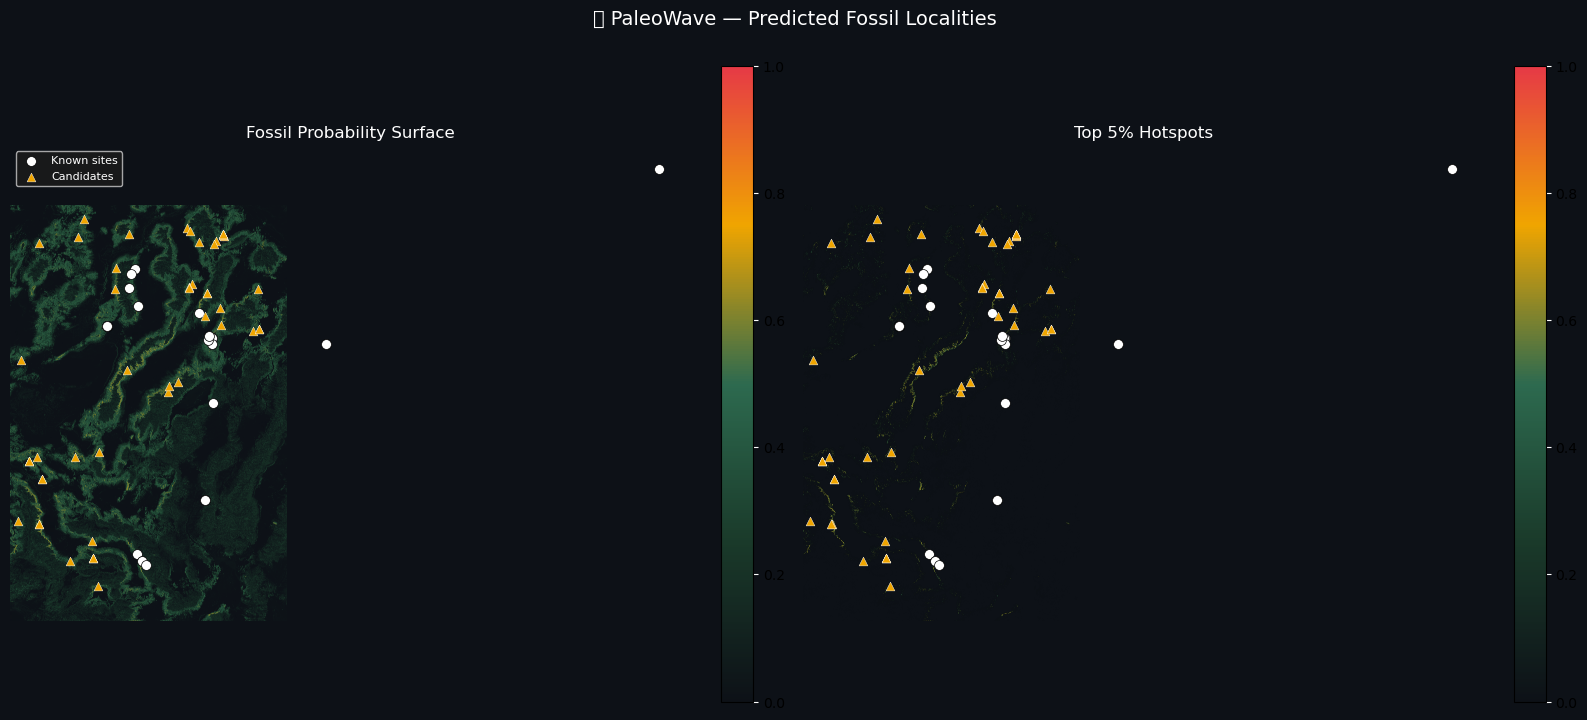

Saved: ..\data\model\prediction_map.png


In [13]:
pw_cmap = LinearSegmentedColormap.from_list(
    'paleowave', ['#0d1117','#1a3a2a','#2d6a4f','#f0a500','#e63946'], N=256)

pbdb = pd.read_csv(DATA_DIR / 'pbdb/pbdb_occurrences_clean.csv')
pbdb_nv = pbdb[pbdb['in_nevada'] == True]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

hotspots = np.where(prob_ds >= np.nanpercentile(prob_ds[prob_ds > 0], 95), prob_ds, np.nan)

for ax, (data_arr, title) in zip(axes, [
    (prob_ds,  'Fossil Probability Surface'),
    (hotspots, 'Top 5% Hotspots'),
]):
    ax.set_facecolor('#0d1117')
    im = ax.imshow(data_arr, cmap=pw_cmap, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')
    ax.set_title(title, color='white', fontsize=12)
    ax.axis('off')
    px = ((pbdb_nv['longitude'] - transform_pred.c) / (transform_pred.a * step)).values
    py = ((pbdb_nv['latitude']  - transform_pred.f) / (transform_pred.e * step)).values
    ax.scatter(px, py, s=50, color='white', edgecolors='black', linewidths=0.5, zorder=5, label='Known sites')
    cx = ((candidates['longitude'] - transform_pred.c) / (transform_pred.a * step)).values
    cy = ((candidates['latitude']  - transform_pred.f) / (transform_pred.e * step)).values
    ax.scatter(cx, cy, s=40, color='#f0a500', marker='^', edgecolors='white', linewidths=0.3, zorder=6, label='Candidates')

axes[0].legend(facecolor='#1c1c1c', labelcolor='white', fontsize=8)
fig.suptitle('🦴 PaleoWave — Predicted Fossil Localities', color='white', fontsize=14, y=1.01)
plt.tight_layout()
map_path = MODEL_DIR / 'prediction_map.png'
plt.savefig(map_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Saved: {map_path}')